# VAE Mark 1

This VAE is heavily inspired by https://www.codecademy.com/article/variational-autoencoder-tutorial-vaes-explained and https://debuggercafe.com/convolutional-variational-autoencoder-in-pytorch-on-mnist-dataset/.

In [1]:
import torch 
import torch.nn as nn # Contains neural network layers.
import torch.optim as optim # Contains Optimisers.
from torch.utils.data import DataLoader 
import torch.nn.functional as F # Contains stateless functions (no internel parameters)
from torchinfo import summary # To get network description
import numpy as np
import wandb # W & B Tracking
import matplotlib.pyplot as plt
import ad_tools.tools as tools # Custom build tools for project
import awkward as ak

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
print(device)

cpu


In [2]:
jz0_train_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", up_row_num=1)
jz0_valid_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 200, up_row_num = 201)
jz0_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 205, up_row_num = 206)
ggF_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/ggF_SM_HH4b.parquet",up_row_num = 1)
vbf_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/VBF_SM_HH4b.parquet",up_row_num = 1)
hs_test_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/HZ_bbvv.parquet",up_row_num = 1)

# Datasets to test phi symmetry
# Approximately a rotation of pi/4,pi/2 and 3pi/4 in phi
transform = lambda x: torch.roll(x, shifts = 16, dims = 2)
jz0_test_pi4_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 215, up_row_num = 216, transform = transform)
transform = lambda x: torch.roll(x, shifts = 32, dims = 2)
jz0_test_pi2_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 225, up_row_num = 226, transform = transform)
transform = lambda x: torch.roll(x, shifts = 48, dims = 2)
jz0_test_3pi4_dataset = tools.DatasetMaker("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", low_row_num = 235, up_row_num = 236, transform = transform)

In [3]:
jz0_train_loader = DataLoader(jz0_train_dataset, batch_size = 1000) 
jz0_valid_loader = DataLoader(jz0_valid_dataset, batch_size = 1000)
jz0_test_loader = DataLoader(jz0_test_dataset, batch_size = 1) 
ggF_test_loader = DataLoader(ggF_test_dataset, batch_size = 1)
jz0_test_pi4_loader = DataLoader(jz0_test_pi4_dataset, batch_size = 1)
jz0_test_pi2_loader = DataLoader(jz0_test_3pi4_dataset, batch_size = 1)
jz0_test_3pi4_loader = DataLoader(jz0_test_3pi4_dataset, batch_size = 1)
vbf_test_loader = DataLoader(vbf_test_dataset, batch_size = 1)
hs_test_loader = DataLoader(hs_test_dataset, batch_size = 1)

## 2. VAE Mark 1

This VAE will use standard convolution layers. This will serve as a benchmark against future VAEs.

In [4]:
class VAEMark1Encoder(nn.Module):
    """
    Encoder using standard convolutional layers.
    """
    
    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = kernel_size)
        self.dropout = nn.Dropout(p = 0.2)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = kernel_size)
        self.pool = nn.MaxPool2d(2) 
        self.flatten = nn.Flatten(start_dim = 1) # Flattens images not the batch itself
        self.mu = nn.Linear(96, latent_dim)
        self.logvar = nn.Linear(96, latent_dim)
        self.circular_padding = nn.CircularPad2d((2,2,0,0))



    def forward(self,input):
        input = self.circular_padding(input)
        output1 = F.leaky_relu(self.conv1(input))
        output1 = output1[:,:,:,2:-2]
        output2 = self.pool(output1) 
        output3 = self.pool(output2)
        output3 = self.circular_padding(output3)
        output4 = F.leaky_relu(self.conv2(output3))
        output4 = output4[:,:,:,2:-2]
        output5 = self.pool(output4)
        output6 = self.pool(output5)
        output7 = self.flatten(output6)
        mu_output = self.mu(output7)
        logvar_output = self.logvar(output7)
        return mu_output, logvar_output

class VAEMark1Decoder(nn.Module):
    """
    Decoder using standard convolution layers.
    """

    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.deconv1 = nn.ConvTranspose2d(in_channels = 16, out_channels = 8, kernel_size = kernel_size)
        self.deconv2 = nn.ConvTranspose2d(in_channels = 8, out_channels = 6, kernel_size = kernel_size)
        self.upsample1 = nn.Upsample(size = (5,6))
        self.upsample2 = nn.Upsample(size = (10,13))
        self.upsample3 = nn.Upsample(size = (24,31))
        self.upsample4 = nn.Upsample(size = (48,62))
        self.linear = nn.Linear(latent_dim,96)
        self.circular_padding = nn.CircularPad2d((2,2,0,0)) # Only adding padding in phi 

    def forward(self, input):
        output1 = self.linear(input)
        output2 = torch.reshape(output1, shape = (-1,16,2,3))
        output3 = self.upsample1(output2)
        output4 = self.upsample2(output3)
        output4 = self.circular_padding(output4)
        output5 = F.leaky_relu(self.deconv1(output4))
        output5 = output5[ : , : , : , 2:-2] # Trimming excess
        output6 = self.upsample3(output5)
        output7 = self.upsample4(output6)
        output7 = self.circular_padding(output7)
        output8 = F.leaky_relu(self.deconv2(output7))
        output8 = output8[:, : , : , 2:-2] # Trimming excess

        return output8

class VAEMark1(nn.Module):
    """
    VAE Mark 1.
    """
    
    def __init__(self, kernel_size = 3, latent_dim = 4):
        super().__init__()
        self.encoder = VAEMark1Encoder(kernel_size = kernel_size, latent_dim = latent_dim)
        self.decoder = VAEMark1Decoder(kernel_size = kernel_size, latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z)
        return output, mu, logvar

In [5]:
inputshape = (1,6,50,64)

model = VAEMark1Encoder()

summary(model,inputshape)

Layer (type:depth-idx)                   Output Shape              Param #
VAEMark1Encoder                          [1, 4]                    --
├─CircularPad2d: 1-1                     [1, 6, 50, 68]            --
├─Conv2d: 1-2                            [1, 8, 48, 66]            440
├─MaxPool2d: 1-3                         [1, 8, 24, 31]            --
├─MaxPool2d: 1-4                         [1, 8, 12, 15]            --
├─CircularPad2d: 1-5                     [1, 8, 12, 19]            --
├─Conv2d: 1-6                            [1, 16, 10, 17]           1,168
├─MaxPool2d: 1-7                         [1, 16, 5, 6]             --
├─MaxPool2d: 1-8                         [1, 16, 2, 3]             --
├─Flatten: 1-9                           [1, 96]                   --
├─Linear: 1-10                           [1, 4]                    388
├─Linear: 1-11                           [1, 4]                    388
Total params: 2,384
Trainable params: 2,384
Non-trainable params: 0
Total mult-

## Training

In [6]:
wandb.login()
project = "TESTING VAEMARK1"
config = {"epochs": 10,"lr":1e-3}


model = VAEMark1().to(device)
optimiser = torch.optim.Adam(model.parameters(), lr = config["lr"]) 

valid_recon_losses = []
valid_kl_losses = []
valid_total_losses = []

train_recon_losses = []
train_kl_losses = []
train_total_losses = []



with wandb.init(project = project, config = config) as run:
    for i in range(config["epochs"]):
        train_avg_recon_loss,train_avg_kl_loss, train_avg_total_loss = tools.train(model = model, dataloader = jz0_train_loader, device = device, optimiser = optimiser,loss_function = tools.unadulterated_training_loss, num_events = 1000)
        train_recon_losses.append(train_avg_recon_loss)
        train_kl_losses.append(train_avg_kl_loss)
        train_total_losses.append(train_avg_total_loss)

        valid_avg_recon_loss,valid_avg_kl_loss, valid_avg_total_loss = tools.valid(model = model, dataloader = jz0_valid_loader, device = device, loss_function = tools.testing_loss, num_events = 1000)
        valid_recon_losses.append(valid_avg_recon_loss)
        valid_kl_losses.append(valid_avg_kl_loss)
        valid_total_losses.append(valid_avg_total_loss)

        run.log({"Training Total Loss": train_avg_total_loss,"Training Reconstruction Loss": train_avg_recon_loss, "Training KL Loss": train_avg_kl_loss, "Validation total loss": valid_avg_total_loss,"Validation Reconstruction Loss": valid_avg_recon_loss, "Validation KL Loss": valid_avg_kl_loss})

        torch.save(model.state_dict(), f'/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_weights/VAEMark1_weights_epoch{i + 1}.pth')
        
        # Saving training and validation losses
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/validation_total_losses.npy", arr = valid_total_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/training_total_losses.npy", arr = train_total_losses)

        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/validation_recon_losses.npy", arr = valid_recon_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/training_recon_losses.npy", arr = train_recon_losses)

        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/validation_kl_losses.npy", arr = valid_kl_losses)
        np.save(file = f"/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_training_validation_losses/training_kl_losses.npy", arr = train_kl_losses)
        print(f"Epoch {i + 1} Complete")

print("Network Training Complete")

wandb: Currently logged in as: theeinspanner (theeinspanner-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1 Complete
Epoch 2 Complete
Epoch 3 Complete
Epoch 4 Complete
Epoch 5 Complete
Epoch 6 Complete
Epoch 7 Complete
Epoch 8 Complete
Epoch 9 Complete
Epoch 10 Complete


Training KL Loss,▂▁▁▁▁▂▃▄▆█
Training Reconstruction Loss,█▆▅▄▃▃▂▂▁▁
Training Total Loss,█▆▅▄▃▃▂▂▁▁
Validation KL Loss,▁▁▁▁▂▂▃▅▆█
Validation Reconstruction Loss,█▇▅▄▃▃▂▂▁▁
Validation total loss,█▇▅▄▃▃▂▂▁▁
Training KL Loss,0.05495
Training Reconstruction Loss,272.51006
Training Total Loss,272.565
Validation KL Loss,0.06529
Validation Reconstruction Loss,247.82797


Network Training Complete


# Trained Network

Stopped Network training on 10 epochs due to validation and training loss flat lining.

In [7]:
model = VAEMark1().to(device)

In [8]:
model.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_weights/VAEMark1_weights_epoch10.pth"))

<All keys matched successfully>

In [9]:
# Testing
jz0_test_mse, jz0_test_kl, jz0_test_total = tools.test(model = model,dataloader = jz0_test_loader,device = device, loss_function = tools.testing_loss)

mse_cutoff= tools.anomaly_cutoff_score(jz0_test_mse)
kl_cutoff= tools.anomaly_cutoff_score(jz0_test_kl)
total_cutoff= tools.anomaly_cutoff_score(jz0_test_total)

In [10]:
ggF_test_mse, ggF_test_kl, ggF_test_total = tools.test(model = model,dataloader = ggF_test_loader,device = device, loss_function = tools.testing_loss)
mse_ggf_signal = tools.signal_acceptance_rate(ggF_test_mse, mse_cutoff)
kl_ggf_signal = tools.signal_acceptance_rate(ggF_test_kl, kl_cutoff)
total_ggf_signal = tools.signal_acceptance_rate(ggF_test_total, total_cutoff)

In [11]:
print(f"The mse ggf singal acceptance rate is {mse_ggf_signal}")
print(f"The kl ggf singal acceptance rate is {kl_ggf_signal}")
print(f"The recon ggf singal acceptance rate is {total_ggf_signal}")

The mse ggf singal acceptance rate is 91.9000015258789
The kl ggf singal acceptance rate is 86.5999984741211
The recon ggf singal acceptance rate is 91.9000015258789


In [12]:
vbf_test_mse, vbf_test_kl, vbf_test_total = tools.test(model = model,dataloader = vbf_test_loader,device = device, loss_function = tools.testing_loss)
mse_vbf_signal = tools.signal_acceptance_rate(vbf_test_mse, mse_cutoff)
kl_vbf_signal = tools.signal_acceptance_rate(vbf_test_kl, kl_cutoff)
total_vbf_signal = tools.signal_acceptance_rate(vbf_test_total, total_cutoff)

In [13]:
print(f"The mse vbf singal acceptance rate is {mse_vbf_signal}")
print(f"The kl vbf singal acceptance rate is {kl_vbf_signal}")
print(f"The recon vbf singal acceptance rate is {total_vbf_signal}")

The mse vbf singal acceptance rate is 81.9000015258789
The kl vbf singal acceptance rate is 77.10000610351562
The recon vbf singal acceptance rate is 81.9000015258789


In [14]:
hs_test_mse, hs_test_kl, hs_test_total = tools.test(model = model,dataloader = hs_test_loader,device = device, loss_function = tools.testing_loss)
mse_hs_signal = tools.signal_acceptance_rate(hs_test_mse, mse_cutoff)
kl_hs_signal = tools.signal_acceptance_rate(hs_test_kl, kl_cutoff)
total_hs_signal = tools.signal_acceptance_rate(hs_test_total, total_cutoff)

In [15]:
print(f"The mse hs singal acceptance rate is {mse_hs_signal}")
print(f"The kl hs singal acceptance rate is {kl_hs_signal}")
print(f"The recon hs singal acceptance rate is {total_hs_signal}")

The mse hs singal acceptance rate is 45.400001525878906
The kl hs singal acceptance rate is 40.099998474121094
The recon hs singal acceptance rate is 45.400001525878906


In [16]:
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1MSECutoff.npy", arr = mse_cutoff)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1KLCutoff.npy", arr = kl_cutoff)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1TotalCutoff.npy", arr = total_cutoff)

In [17]:
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1MSEggFsignalrate.npy", arr = mse_ggf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1KLggFsignalrate.npy", arr = kl_ggf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1TotalggFsignalrate.npy", arr = total_ggf_signal)

np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1MSEvbfsignalrate.npy", arr = mse_vbf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1KLvbfsignalrate.npy", arr = kl_vbf_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1Totalvbfsignalrate.npy", arr = total_vbf_signal)

np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1MSEhssignalrate.npy", arr = mse_hs_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1KLhssignalrate.npy", arr = kl_hs_signal)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_signal_acceptance_rates/VAEMark1Totalhssignalrate.npy", arr = total_hs_signal)

In [18]:
_,_,jz0_test_pi4_losses = tools.test(model = model,dataloader = jz0_test_pi4_loader,device = device, loss_function = tools.testing_loss)
_,_,jz0_test_pi2_losses = tools.test(model = model,dataloader = jz0_test_pi2_loader,device = device, loss_function = tools.testing_loss)
_,_,jz0_test_3pi4_losses = tools.test(model = model,dataloader = jz0_test_3pi4_loader,device = device, loss_function = tools.testing_loss)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_phi_invariance_study/jz0pi4loss.npy", arr = jz0_test_pi4_losses)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_phi_invariance_study/jz0pi2loss.npy", arr = jz0_test_pi2_losses)
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_phi_invariance_study/jz03pi4loss.npy", arr = jz0_test_3pi4_losses)

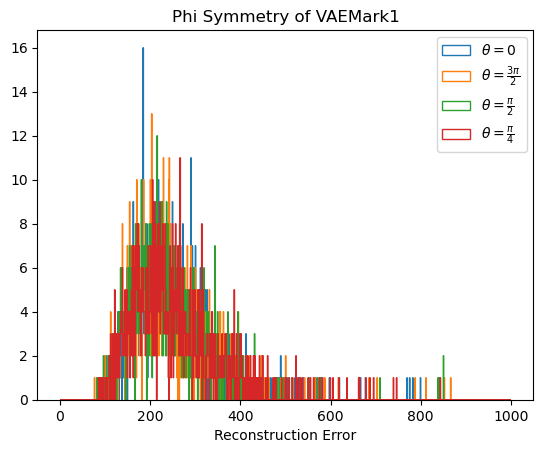

In [19]:
plt.hist(jz0_test_total, bins = 1000, range = (0,1000), histtype= "step", label = r"$\theta = 0$")
plt.hist(jz0_test_3pi4_losses, bins = 1000, range = (0,1000), histtype= "step", label = r"$\theta = \frac{3\pi}{2}$")
plt.hist(jz0_test_pi2_losses, bins = 1000, range = (0,1000), histtype= "step",label = r"$\theta = \frac{\pi}{2}$")
plt.hist(jz0_test_pi4_losses, bins = 1000, range = (0,1000), histtype= "step",label = r"$\theta = \frac{\pi}{4}$")
plt.legend()
plt.xlabel("Reconstruction Error")
plt.title("Phi Symmetry of VAEMark1")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/original_loss_phi_invariance_study/original_phi_symmetry_VAEMark1.png")

# Evaluate Neural Network Output

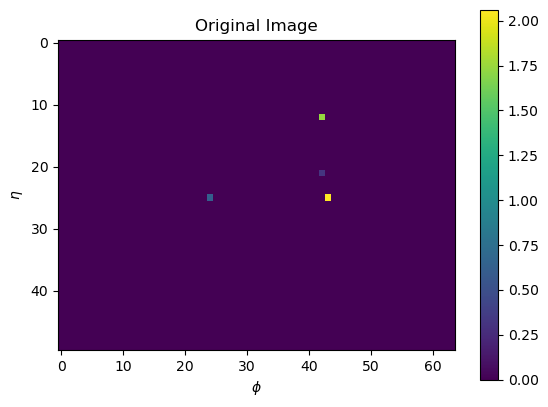

In [20]:
jz0 = ak.from_parquet("/home/xzcapask/ad_trigger_data/JZ0_no_filter.parquet", columns = "cell_towers", row_groups=range(205,206))
jz0 = ak.to_torch(jz0.cell_towers).to(torch.float32)

# Pileup supression
for i in range(len(jz0)):
    image_summed = torch.sum(jz0[i], axis = -1)
    image_eta, image_phi = torch.where(image_summed < 2)
    for j in range(len(image_eta)):      
        jz0[i,image_eta[j], image_phi[j],:] = 0 

plt.imshow(jz0[0,:,:,0])
plt.title("Original Image")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/OriginalVAEMark1Inputtestimage.png")

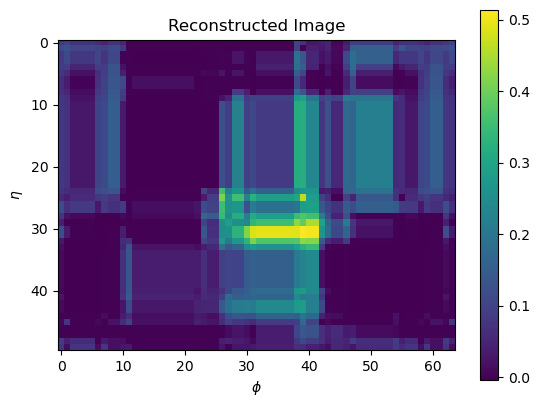

In [21]:
testimage = torch.permute(jz0[0], dims = (2,0,1)).reshape(-1,6,50,64)
testimage.shape
recon_image,mu,logvar = model(testimage)
plt.imshow(recon_image[0,0].detach().numpy())
plt.title("Reconstructed Image")
plt.xlabel("$\phi$")
plt.ylabel("$\eta$")
plt.colorbar()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/VAEMark1/ReconstructedVAEMark1Inputtestimage.png")